# Regression on Real Data: Predicting House Prices

**This notebook is self-contained; it recaps multiple regression before applying it.**

Everything in §3.7 so far used small or synthetic data where the true answer was known. This is the
capstone: **a table of real house sales with dozens of recorded attributes**, and a genuine
question: how well can we
predict the sale price, and which attributes actually matter?

Real data brings problems the synthetic examples did not: missing values, non-numeric columns,
outliers, and features measured on wildly different scales. Handling those *is* the work.

## Learning objectives

- Prepare a messy real table for regression: select, clean, and filter.
- Fit models with increasing numbers of features and measure **diminishing returns**.
- Interpret the result honestly, using held-out data.

## Background

The model and the machinery are unchanged from `U3-7_Regression-4_MatrixForm`:
$\hat{\mathbf{y}} = X\mathbf{b}$, fitted by the
normal equations. What changes is everything *around* it.

Three preparation steps matter here:

- **Numeric columns only.** Regression needs numbers; text categories like `"2-STORY 1946 & NEWER"`
  have to be dropped or encoded.
- **Missing values.** A single `NaN` propagates through the arithmetic and destroys the fit.
- **Outliers.** A handful of extreme houses can drag a least-squares fit noticeably, because squaring
  the residuals gives them outsized influence, a direct consequence of the choice made in `U3-7_Regression-1_FittingALine`.

We evaluate with **mean absolute error** (MAE) as well as $r^2$, because MAE is in dollars and is
therefore something a person can judge.

**Note:** this is the same table §2.7 used for PCA. There it was compressed into components; here it
is used to predict.

## This notebook covers

1. Loading and inspecting a wide, messy table.
2. Cleaning: numeric columns, missing values, outliers.
3. One feature, then several.
4. Diminishing returns as features are added.
5. An honest evaluation on held-out data.

**Prerequisites:** `U3-7_Regression-5_MultipleFeatures`

**Dataset:** `Real Estate Data.csv`, house sales with dozens of attributes, from the shared
dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(0)

## 1. A wide, messy table

69 columns of mixed types, measurements, quality ratings, and text categories.

In [2]:
homes = pd.read_csv(helpers.data('Real Estate/Real Estate Data.csv'), index_col=0)
homes = homes.rename(columns={'OvQual': 'Overall Qual', 'Built': 'Year Built'})

print(f"{homes.shape[0]} houses, {homes.shape[1]} columns")
print(f"\ncolumn types:\n{homes.dtypes.value_counts().to_string()}")
homes[['Living Area Above Grade', 'Overall Qual', 'Year Built', 'Sale Price']].head()

1404 houses, 68 columns

column types:
object     37
int64      28
float64     3


,Living Area Above Grade,Overall Qual,Year Built,Sale Price
Id,,,,
1,1710,7,2003,208500
2,1262,6,1976,181500
3,1786,7,2001,223500
4,1717,7,1915,140000
5,2198,8,2000,250000


## 2. Cleaning

Three steps, each for a specific reason.

**Numeric only.** Text categories cannot enter the arithmetic.

**Drop missing values.** A `NaN` anywhere propagates through every matrix product.

**Filter outliers.** Points more than three standard deviations from the mean get removed. Note the
implementation detail: the mask is computed **across all columns at once and applied once**. Filtering
column by column in a loop would make the result depend on column order, which is a subtle and nasty
bug.

In [3]:
numeric = homes.select_dtypes(include=np.number)
print(f"numeric columns: {numeric.shape[1]} of {homes.shape[1]}")

numeric = numeric.dropna(axis=1)            # drop columns with any missing values
print(f"after dropping columns with missing values: {numeric.shape[1]}")

# outlier mask, computed across ALL columns at once and applied once --
# doing this column-by-column in a loop would make the result order-dependent
z = (numeric - numeric.mean()) / numeric.std()
keep = (z.abs() < 3).all(axis=1)
clean = numeric[keep]

print(f"\nhouses before filtering: {len(numeric)}")
print(f"houses after filtering : {len(clean)}   ({(~keep).sum()} removed as outliers)")

numeric columns: 31 of 68
after dropping columns with missing values: 28

houses before filtering: 1404
houses after filtering : 1050   (354 removed as outliers)


## 3. One feature, then several

Start with the single most obvious predictor, living area, and build up.

In [4]:
y = clean['Sale Price'].values
predictors = [c for c in clean.columns if c != 'Sale Price']

single = clean[['Living Area Above Grade']].values
model1 = LinearRegression().fit(single, y)
pred1 = model1.predict(single)

print(f"price = {model1.intercept_:,.0f} + {model1.coef_[0]:,.1f} x living area")
print(f"\nr^2  = {r2_score(y, pred1):.4f}")
print(f"MAE  = ${mean_absolute_error(y, pred1):,.0f}   (typical miss)")
print(f"\nfor reference, prices range ${y.min():,.0f} to ${y.max():,.0f}, mean ${y.mean():,.0f}")

price = 18,665 + 108.5 x living area

r^2  = 0.5478
MAE  = $30,994   (typical miss)

for reference, prices range $40,000 to $412,500, mean $176,229


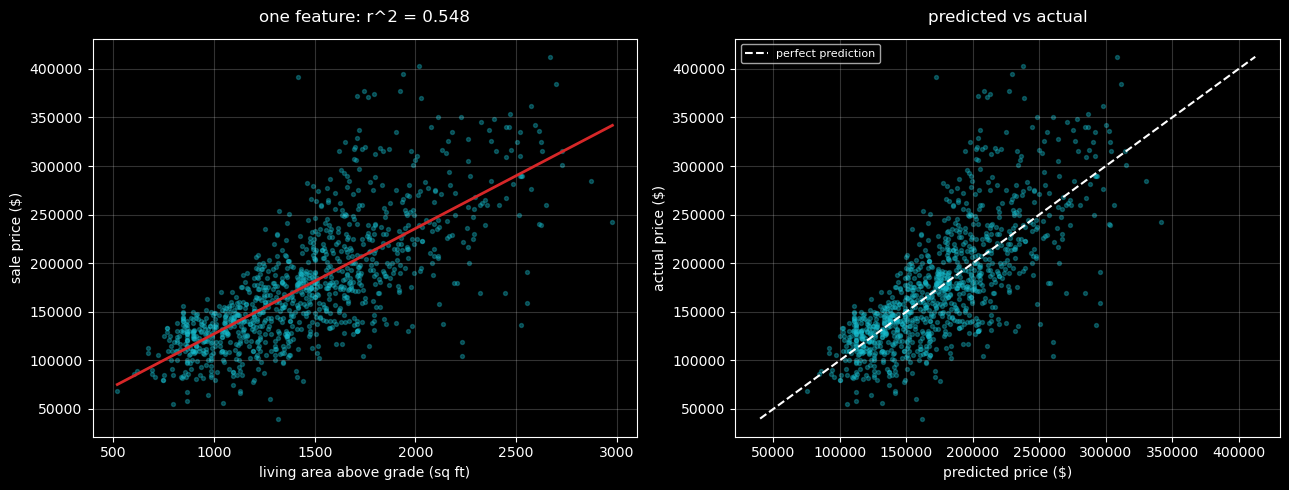

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(single.ravel(), y, s=8, alpha=0.35, color="tab:cyan", rasterized=True)
grid = np.linspace(single.min(), single.max(), 50)
axes[0].plot(grid, model1.predict(grid.reshape(-1, 1)), color="tab:red", lw=2)
axes[0].set_xlabel("living area above grade (sq ft)")
axes[0].set_ylabel("sale price ($)")
axes[0].set_title(f"one feature: r^2 = {r2_score(y, pred1):.3f}", pad=12)

axes[1].scatter(pred1, y, s=8, alpha=0.35, color="tab:cyan", rasterized=True)
lim = [y.min(), y.max()]
axes[1].plot(lim, lim, "--", color="white", lw=1.5, label="perfect prediction")
axes[1].set_xlabel("predicted price ($)")
axes[1].set_ylabel("actual price ($)")
axes[1].legend(fontsize=8)
axes[1].set_title("predicted vs actual", pad=12)

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# add features one at a time, in order of how strongly each correlates with price
corr = clean[predictors].corrwith(clean['Sale Price']).abs().sort_values(ascending=False)
print("the ten predictors most correlated with sale price:\n")
print(corr.head(10).to_string())

the ten predictors most correlated with sale price:

Overall Qual               0.808478
Living Area Above Grade    0.740128
Garage Cars                0.694369
Garage Area                0.657384
Full Baths Above Grade     0.649811
Year Built                 0.620171
Basement Area              0.608995
Total Rooms Above Grade    0.572193
1st Floor Area             0.571936
Year Remod Add             0.552790


## 4. Diminishing returns

Now the central experiment: add features in order of usefulness and watch the error fall. It does, but by less and less. The first few features do nearly all the work; by the twentieth the curve is nearly
flat.

This is the practical reason feature selection exists. A model with 8 well-chosen features gets most
of the way to one using every available column, while being faster, more stable, and vastly easier to
explain to whoever has to act on it.

In [7]:
order = list(corr.index)

results = []
for k in range(1, len(order) + 1):
    F = clean[order[:k]].values
    Xtr, Xte, ytr, yte = train_test_split(F, y, test_size=0.3, random_state=0)
    mdl = LinearRegression().fit(Xtr, ytr)
    results.append({
        'k': k,
        'train_r2': mdl.score(Xtr, ytr),
        'test_r2': mdl.score(Xte, yte),
        'test_mae': mean_absolute_error(yte, mdl.predict(Xte)),
    })
res = pd.DataFrame(results)

print(f"{'features':>9} {'train r^2':>11} {'test r^2':>10} {'test MAE':>12}")
print("-" * 46)
for k in [1, 2, 3, 5, 8, 12, 20, len(order)]:
    row = res[res.k == k].iloc[0]
    print(f"{k:>9} {row.train_r2:11.4f} {row.test_r2:10.4f} ${row.test_mae:11,.0f}")

 features   train r^2   test r^2     test MAE
----------------------------------------------
        1      0.6447     0.6715 $     27,137
        2      0.7602     0.7402 $     23,947
        3      0.7991     0.7693 $     22,331
        5      0.8079     0.7725 $     22,416
        8      0.8459     0.8207 $     19,696
       12      0.8540     0.8289 $     19,347
       20      0.8819     0.8597 $     17,262
       27      0.8837     0.8663 $     16,751


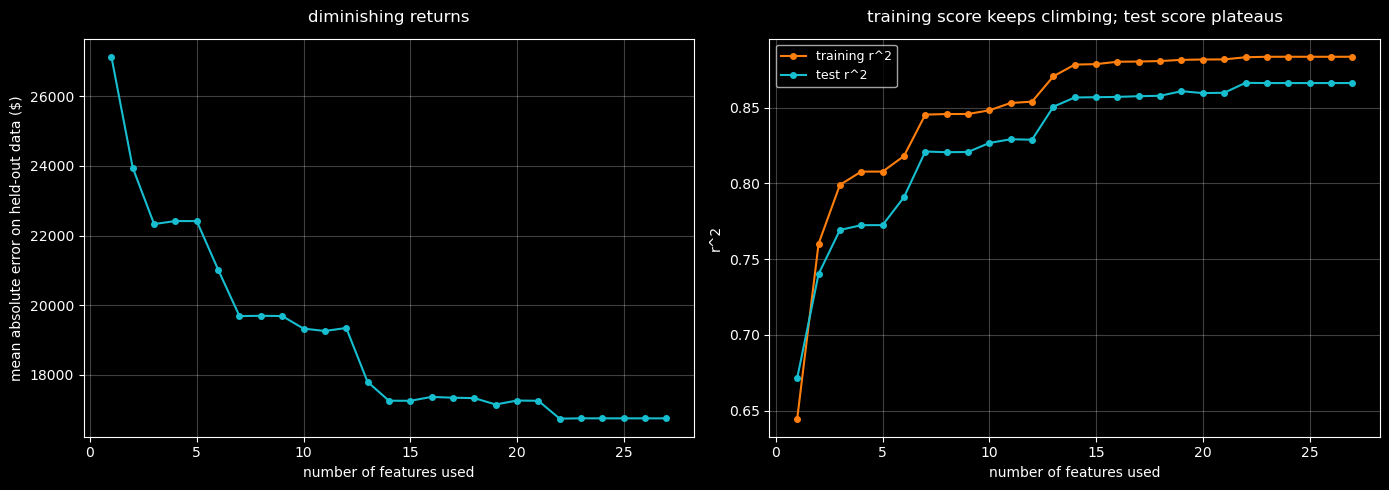

1 feature   : test MAE $27,137
8 features  : test MAE $19,696   (27% better than one)
27 features : test MAE $16,751   (15.0% better than eight)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(res.k, res.test_mae, "o-", color="tab:cyan", markersize=4)
axes[0].set_xlabel("number of features used")
axes[0].set_ylabel("mean absolute error on held-out data ($)")
axes[0].set_title("diminishing returns", pad=12)
axes[0].grid(alpha=0.25)

axes[1].plot(res.k, res.train_r2, "o-", color="tab:orange", markersize=4, label="training r^2")
axes[1].plot(res.k, res.test_r2, "o-", color="tab:cyan", markersize=4, label="test r^2")
axes[1].set_xlabel("number of features used")
axes[1].set_ylabel("r^2")
axes[1].legend(fontsize=9)
axes[1].set_title("training score keeps climbing; test score plateaus", pad=12)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

first = res.iloc[0]; eight = res[res.k == 8].iloc[0]; last = res.iloc[-1]
print(f"1 feature   : test MAE ${first.test_mae:,.0f}")
print(f"8 features  : test MAE ${eight.test_mae:,.0f}   "
      f"({(1 - eight.test_mae/first.test_mae)*100:.0f}% better than one)")
print(f"{len(order)} features : test MAE ${last.test_mae:,.0f}   "
      f"({(1 - last.test_mae/eight.test_mae)*100:.1f}% better than eight)")

The gap between the two curves in the right panel is exactly the **overfitting** measured in the
previous notebook, now on real data: the training score keeps improving because the model keeps
absorbing the training set's particular quirks, while the test score, the one that matters, flattens.

## 5. An honest final model

Settle on a modest set of features, fit on the training portion, and report performance on data the
model has never seen. That last number is the only one worth quoting to anyone.

In [9]:
chosen = order[:8]
F = clean[chosen].values
Xtr, Xte, ytr, yte = train_test_split(F, y, test_size=0.3, random_state=0)

final = LinearRegression().fit(Xtr, ytr)
pred_te = final.predict(Xte)

print("features used:")
for nm, coef in zip(chosen, final.coef_):
    print(f"   {nm:<28} {coef:+14,.2f}")
print(f"   {'(intercept)':<28} {final.intercept_:+14,.2f}")

print(f"\nheld-out performance on {len(yte)} unseen houses:")
print(f"   r^2 = {r2_score(yte, pred_te):.4f}")
print(f"   MAE = ${mean_absolute_error(yte, pred_te):,.0f}")
print(f"   -- so a typical prediction is off by about "
      f"{mean_absolute_error(yte, pred_te)/yte.mean()*100:.0f}% of the average price")

features used:
   Overall Qual                     +15,461.70
   Living Area Above Grade              +54.25
   Garage Cars                       +6,880.55
   Garage Area                          +37.61
   Full Baths Above Grade            -8,326.70
   Year Built                          +315.84
   Basement Area                        +34.58
   Total Rooms Above Grade           +1,545.66
   (intercept)                     -683,692.23

held-out performance on 315 unseen houses:
   r^2 = 0.8207
   MAE = $19,696
   -- so a typical prediction is off by about 11% of the average price


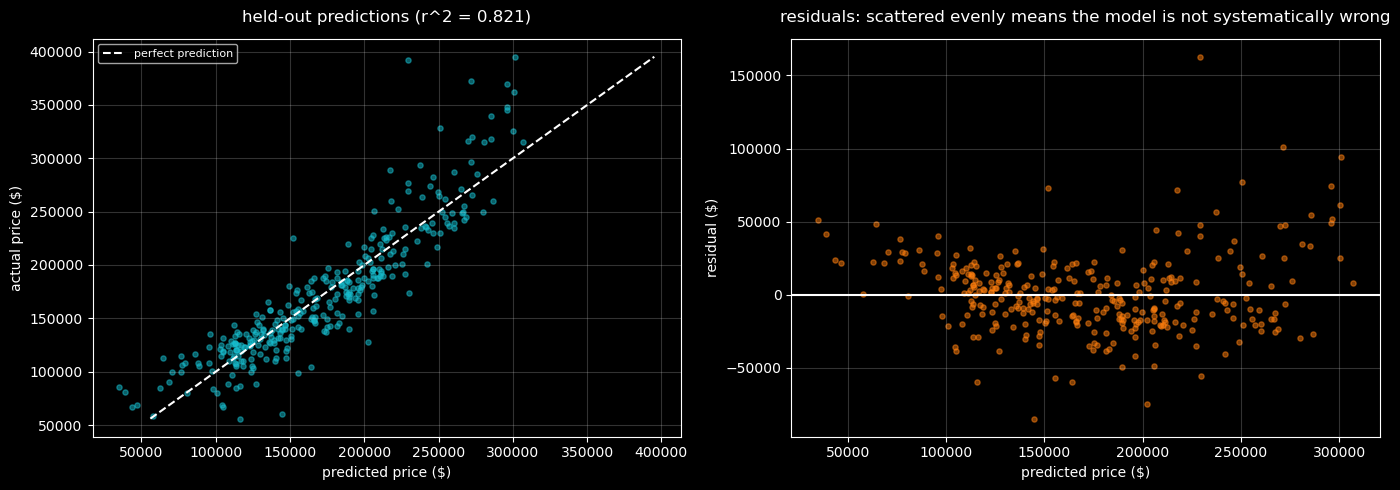

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_te, yte, s=14, alpha=0.5, color="tab:cyan", rasterized=True)
lim = [yte.min(), yte.max()]
axes[0].plot(lim, lim, "--", color="white", lw=1.5, label="perfect prediction")
axes[0].set_xlabel("predicted price ($)"); axes[0].set_ylabel("actual price ($)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)
axes[0].set_title(f"held-out predictions (r^2 = {r2_score(yte, pred_te):.3f})", pad=12)

resid = yte - pred_te
axes[1].scatter(pred_te, resid, s=14, alpha=0.5, color="tab:orange", rasterized=True)
axes[1].axhline(0, color="white", lw=1.5)
axes[1].set_xlabel("predicted price ($)"); axes[1].set_ylabel("residual ($)")
axes[1].grid(alpha=0.2)
axes[1].set_title("residuals: scattered evenly means the model is not systematically wrong", pad=12)

plt.tight_layout()
plt.show()

## 6. Summary

- Real data needs **preparation**: numeric columns only, missing values handled, outliers filtered,   and the outlier mask computed **once across all columns**, never in a per-column loop.
- The first few features do nearly all the work; returns **diminish sharply** after that.
- **Training score keeps rising while test score plateaus**: overfitting, visible on real data.
- Report **held-out** performance, and in interpretable units (MAE in dollars) alongside $r^2$.

**That closes §3.7 and the ML on-ramp.** The path was: gradient descent → what "best fit" means →
how good the fit is → three ways to find it → the matrix form → many features → real data. You have
trained a machine-learning model end to end and know what every step does.

The same table appears in `U2-7_PCA-2_RealEstate`, where it was compressed rather than predicted, two different questions about one dataset.

Next: the other half of calculus, accumulating quantities rather than measuring their rate of change
(`U3-8_Integrals-1_RiemannSums`).